# Лабораторная работа: Численные методы

- Студент: Платов Дмитрий Константинович
- Группа: 6
- Дата: 28.03.26
- Весь код в файле ".py": https://github.com/PlatovD/numerical_methods_for_solving_nonlinear_equations

## Цель работы
Изучение численных методов интегрирования с использованием Python.

<br><br>
## Ход работы

### 0. Импорт необходимых библиотек, задание констант

Здесь я импортирую библиотеки для работы с данными, для их визуализации. Так же использую библиотеку ABC, чтобы использовать преимущества ООП и делать код более унифицированным 

In [3]:
from abc import ABC
import random

import matplotlib.pyplot as plt
import numpy as np

ANALYTIC_VALUE = -18.11347301218
ANALYTIC_VALUE_TRIPLE = 0.037037037

### 1. Создание вспомогательного класса для визуализации 

Drawer позволит нам строить графики зависимости точности расчета интеграла от числа отрезков разбиения, а так же поможет визуализировать зависимость между требуемой точностью и числом интервалов

In [4]:
class Drawer:
    @staticmethod
    def plot_n_vs_accuracy(
            integrator_classes: list['NumericalIntegrator'],
            method_names: list[str],
            a: float,
            b: float,
            func: callable,
            accuracy_values: list[float],
            title: str = "Зависимость количества интервалов от требуемой точности"
    ):
        plt.figure(figsize=(10, 6))
        colors = ['blue', 'green', 'red', 'purple', 'orange']

        for integrator_class, method_name, color in zip(integrator_classes, method_names, colors):
            n_values = []

            for accuracy in accuracy_values:
                _, n_actual = integrator_class.integrate_with_accuracy([a, b], func, accuracy)
                n_values.append(n_actual)

            plt.loglog(accuracy_values, n_values, '-', linewidth=2,
                       label=method_name, color=color)

        plt.xlabel('Требуемая точность ε', fontsize=12)
        plt.ylabel('Количество интервалов N', fontsize=12)
        plt.title(title, fontsize=12)
        plt.grid(True, alpha=0.3, which='both')
        plt.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_errors(
            integrator_class: 'NumericalIntegrator',
            exact_value: float,
            a: float,
            b: float,
            func: callable,
            n_values: [int],
            method_name: str = "",
            y_lim_absolute: tuple[float] = (0, 20),
            y_lim_rel: tuple[float] = (1e-3, 3),
    ):
        abs_errors = []
        rel_errors = []

        for n in n_values:
            approx = integrator_class.integrate([a, b], func, n)

            abs_error = abs(approx - exact_value)
            rel_error = abs_error / abs(exact_value) if exact_value != 0 else abs_error

            abs_errors.append(abs_error)
            rel_errors.append(rel_error)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        ax1.plot(n_values, abs_errors, 'o-', linewidth=2, markersize=6)
        ax1.set_xlabel('Количество интервалов n', fontsize=12)
        ax1.set_ylabel('Абсолютная погрешность', fontsize=12)
        ax1.set_title(f'Абсолютная погрешность\n{method_name}', fontsize=12)
        if y_lim_absolute:
            ax1.set_ylim(*y_lim_absolute)
        ax1.grid(True, alpha=0.3)

        ax2.plot(n_values, rel_errors, 'o-', linewidth=2, markersize=6, color='orange')
        ax2.set_xlabel('Количество интервалов n', fontsize=12)
        ax2.set_ylabel('Относительная погрешность', fontsize=12)
        ax2.set_title(f'Относительная погрешность\n{method_name}', fontsize=12)
        if y_lim_rel:
            ax2.set_ylim(*y_lim_rel)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return abs_errors, rel_errors

    @staticmethod
    def plot_all_methods_errors(
            integrator_classes: ['NumericalIntegrator'],
            method_names: [str],
            exact_value: float,
            borders: [float],
            func: callable,
            n_values: [int],
            y_lim_absolute: tuple[float] = (0, 20),
            y_lim_rel: tuple[float] = (1e-3, 3),
            title: str = None,
            method_from_getattr_name: str = 'integrate'
    ):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        colors = ['blue', 'green', 'red', 'purple', 'orange']

        for integrator_class, method_name, color in zip(integrator_classes, method_names, colors):
            abs_errors = []
            rel_errors = []
            method = getattr(integrator_class, method_from_getattr_name)
            for n in n_values:
                approx = method(borders, func, n)

                abs_error = abs(approx - exact_value)
                rel_error = abs_error / abs(exact_value) if exact_value != 0 else abs_error

                abs_errors.append(abs_error)
                rel_errors.append(rel_error)

            ax1.plot(n_values, abs_errors, 'o-', linewidth=2, markersize=4,
                     label=method_name, color=color)
            ax1.set_yscale('log')
            ax2.loglog(n_values, rel_errors, 'o-', linewidth=2, markersize=4,
                       label=method_name, color=color)
            ax2.set_yscale('log')

        ax1.set_xlabel('Количество интервалов n', fontsize=12)
        ax1.set_ylabel('Абсолютная погрешность', fontsize=12)
        ax1.set_title('Сравнение абсолютной погрешности', fontsize=12)
        if y_lim_absolute:
            ax1.set_ylim(*y_lim_absolute)
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc=1)

        ax2.set_xlabel('Количество интервалов n', fontsize=12)
        ax2.set_ylabel('Относительная погрешность', fontsize=12)
        ax2.set_title('Сравнение относительной погрешности', fontsize=12)
        if y_lim_rel:
            ax2.set_ylim(*y_lim_rel)
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc=1)

        if title:
            fig.suptitle(title)
        plt.tight_layout()
        plt.show()

### 2. Алгоритмы численного интегрирования 

Абстрактный интерфейс интегратора. Реализация методов численного интегрирования: левые, правые, средние прямоугольники, метод трапеций, метод Симпсона и Монте-Карло  

In [8]:
class NumericalIntegrator(ABC):
    @staticmethod
    def _build_intervals(borders: [], intervals_cnt: int):
        l, r = borders
        step = (r - l) / intervals_cnt
        intervals = np.linspace(l + step, r, intervals_cnt)
        return [(intervals[i], intervals[i + 1])
                for i in range(intervals.shape[0] - 1)]

    @staticmethod
    def integrate(borders: [], func: callable, intervals_cnt: int):
        pass

    @staticmethod
    def integrate_with_accuracy(borders: [], func: callable, accuracy, max_iterations=100000) -> (int, int):
        pass

    @staticmethod
    def integrate_triple(borders_x_y_z: [], func: callable, intervals_cnt: int):
        pass


class LeftRectangleMethod(NumericalIntegrator):
    @staticmethod
    def integrate_with_accuracy(borders: [], func: callable, accuracy, max_iterations=5000000):
        l, r = 1, max_iterations
        good_iter_cnt = max_iterations // 2 + max_iterations // 6
        while l <= r:
            m = l + (r - l) // 2
            if abs(LeftRectangleMethod.integrate(borders, func, m) - LeftRectangleMethod.integrate(
                    borders, func, 2 * m)) <= accuracy:
                good_iter_cnt = m
                r = m - 1
            else:
                l = m + 1
        return RightRectangleMethod.integrate(borders, func, good_iter_cnt), good_iter_cnt

    @staticmethod
    def integrate_triple(borders_x_y_z: [], func: callable, intervals_cnt: int):
        x_0, x_1, y_0, y_1, z_0, z_1 = borders_x_y_z
        intervals_x = LeftRectangleMethod._build_intervals([x_0, x_1], intervals_cnt)
        intervals_y = LeftRectangleMethod._build_intervals([y_0, y_1], intervals_cnt)
        intervals_z = LeftRectangleMethod._build_intervals([z_0, z_1], intervals_cnt)
        return sum(
            func(x[0], y[0], z[0]) * ((x[1] - x[0]) * (y[1] - y[0]) * (z[1] - z[0])) for z in intervals_z for y in
            intervals_y for x in intervals_x)

    @staticmethod
    def integrate(borders: [], func: callable, intervals_cnt: int):
        l, r = borders
        step = (r - l) / intervals_cnt
        x = np.linspace(l, r - step, intervals_cnt)
        return (f(x) * step).sum()


class RightRectangleMethod(NumericalIntegrator):
    @staticmethod
    def integrate_with_accuracy(borders: [], func: callable, accuracy, max_iterations=5000000):
        l, r = 1, max_iterations
        good_iter_cnt = max_iterations // 2
        while l <= r:
            m = l + (r - l) // 2
            if abs(RightRectangleMethod.integrate(borders, func, m) - RightRectangleMethod.integrate(
                    borders, func, 2 * m)) <= accuracy:
                good_iter_cnt = m
                r = m - 1
            else:
                l = m + 1
        return RightRectangleMethod.integrate(borders, func, good_iter_cnt), good_iter_cnt

    @staticmethod
    def integrate(borders: [], func: callable, intervals_cnt: int):
        l, r = borders
        step = (r - l) / intervals_cnt
        x = np.linspace(l + step, r, intervals_cnt)
        return (f(x) * step).sum()


class MiddleRectangleMethod(NumericalIntegrator):
    @staticmethod
    def integrate_with_accuracy(borders: [], func: callable, accuracy, max_iterations=1000):
        l, r = 1, max_iterations
        good_iter_cnt = max_iterations // 2
        while l <= r:
            m = l + (r - l) // 2
            if abs(MiddleRectangleMethod.integrate(borders, func, m) - MiddleRectangleMethod.integrate(borders, func,
                                                                                                       2 * m)) / 3 <= accuracy:
                good_iter_cnt = m
                r = m - 1
            else:
                l = m + 1
        return MiddleRectangleMethod.integrate(borders, func, good_iter_cnt), good_iter_cnt

    @staticmethod
    def integrate(borders: [], func: callable, intervals_cnt: int):
        intervals = MiddleRectangleMethod._build_intervals(borders, intervals_cnt)
        return sum(func((interval[1] + interval[0]) / 2) * (interval[1] - interval[0]) for interval in
                   intervals)


class TrapezoidMethod(NumericalIntegrator):
    @staticmethod
    def integrate(borders: [], func: callable, intervals_cnt: int):
        intervals = TrapezoidMethod._build_intervals(borders, intervals_cnt)
        return sum((func(interval[1]) + func(interval[0])) / 2 * (interval[1] - interval[0]) for interval in
                   intervals)

    @staticmethod
    def integrate_with_accuracy(borders: [], func: callable, accuracy, max_iterations=10000):
        l, r = 1, max_iterations
        good_iter_cnt = max_iterations // 2
        while l <= r:
            m = l + (r - l) // 2
            if abs(TrapezoidMethod.integrate(borders, func, m) - TrapezoidMethod.integrate(borders, func,
                                                                                           2 * m)) / 3 <= accuracy:
                good_iter_cnt = m
                r = m - 1
            else:
                l = m + 1
        return TrapezoidMethod.integrate(borders, func, good_iter_cnt), good_iter_cnt


class SimpsonMethod(NumericalIntegrator):
    @staticmethod
    def integrate(borders: [], func: callable, intervals_cnt: int):
        intervals = SimpsonMethod._build_intervals(borders, intervals_cnt)
        return sum(
            (func(interval[0]) + 4 * func(interval[1]) + func(interval[2])) / 6 * (
                    interval[2] - interval[0]) for interval in intervals)

    @staticmethod
    def integrate_with_accuracy(borders: [], func: callable, accuracy, max_iterations=10000):
        l, r = 2, max_iterations
        good_iter_cnt = max_iterations // 2
        while l <= r:
            m = l + (r - l) // 2
            if abs(SimpsonMethod.integrate(borders, func, m) - SimpsonMethod.integrate(borders, func,
                                                                                       2 * m)) / 15 <= accuracy:
                good_iter_cnt = m
                r = m - 1
            else:
                l = m + 1
        return SimpsonMethod.integrate(borders, func, good_iter_cnt), good_iter_cnt

    @staticmethod
    def _build_intervals(borders: [], intervals_cnt: int):
        if intervals_cnt % 2 != 0:
            intervals_cnt -= 1
        l, r = borders
        intervals = []
        step = (r - l) / intervals_cnt
        for i in range(intervals_cnt // 2):
            intervals.append((l + (i * 2 * step), (l + ((i * 2 + 1) * step)), (l + ((i * 2 + 2) * step))))
        return intervals


class MonteCarloMethod:
    @staticmethod
    def integrate(borders: [], func: callable, random_points_cnt: int):
        return (borders[1] - borders[0]) / random_points_cnt * sum(
            func(random.uniform(borders[0], borders[1])) for _ in range(random_points_cnt))

    @staticmethod
    def integrate_triple(borders_x_y_z: [], func: callable, random_points_cnt: int):
        random_points_cnt = pow(random_points_cnt, 3)
        x_0, x_1, y_0, y_1, z_0, z_1 = borders_x_y_z
        return ((x_1 - x_0) * (y_1 - y_0) * (z_1 - z_0)) / random_points_cnt * sum(
            func(random.uniform(x_0, x_1), random.uniform(y_0, y_1),
                 random.uniform(z_0, z_1)) for _ in range(random_points_cnt))

### 3. Определение математических функций

In [6]:
def f(x: float):
    return np.pow(x, 2) * np.sin(x)


def f1(x: float, y: float, z: float):
    return x ** 2 * y ** 2 * z ** 2

### 4.Задание 1 

В этом пункте требуется для каждого из методов построить зависимость абсолютной и относительной погрешности от числа промежутков разбиения. Используя все то, что было задано ранее сделаем это: 

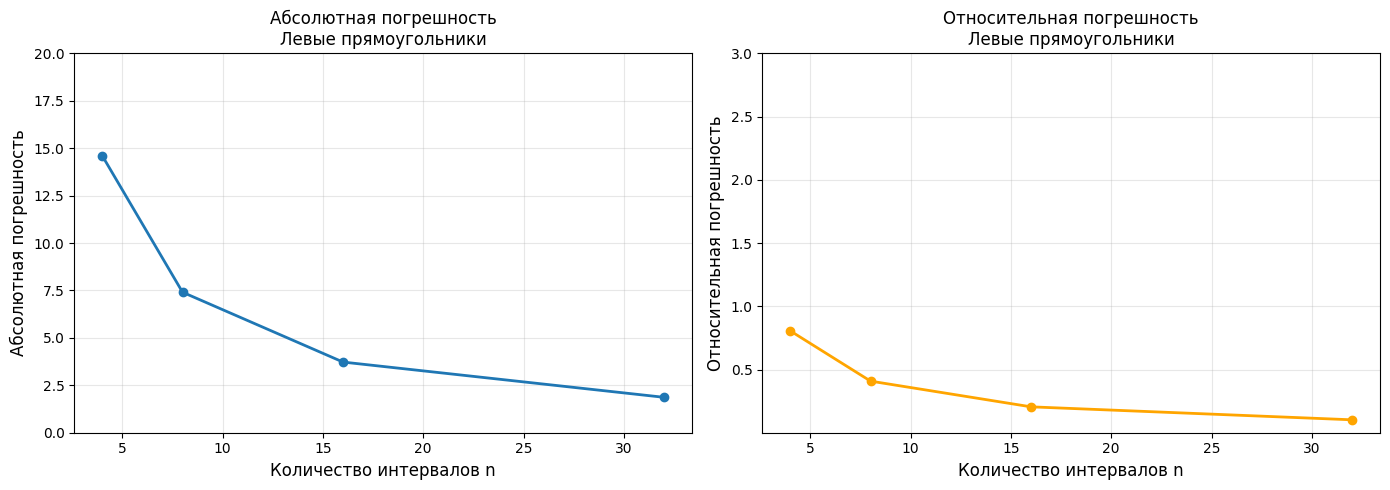

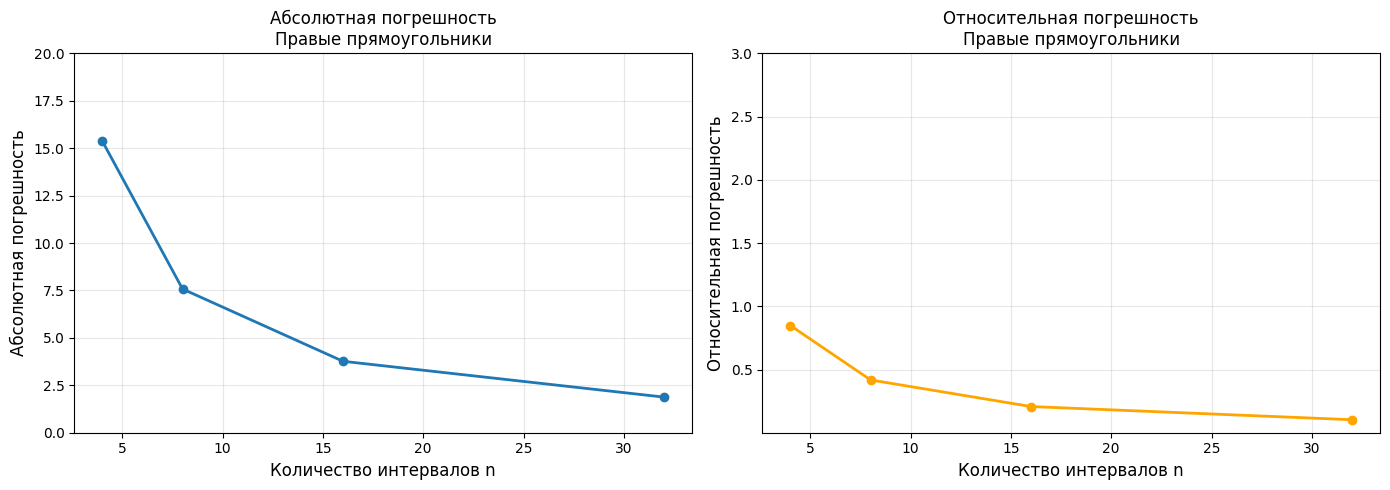

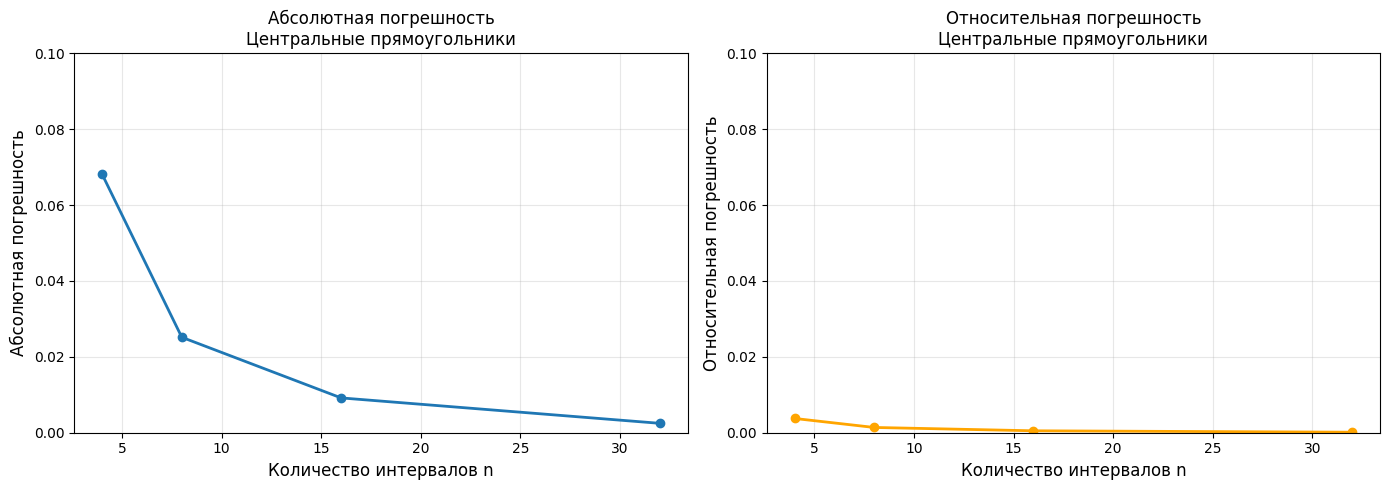

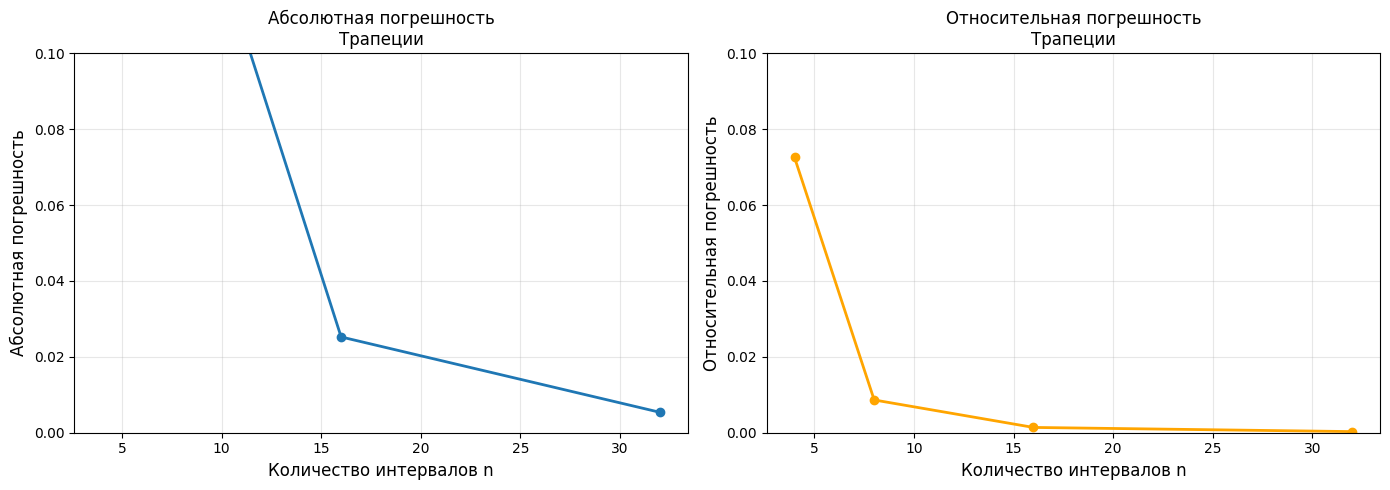

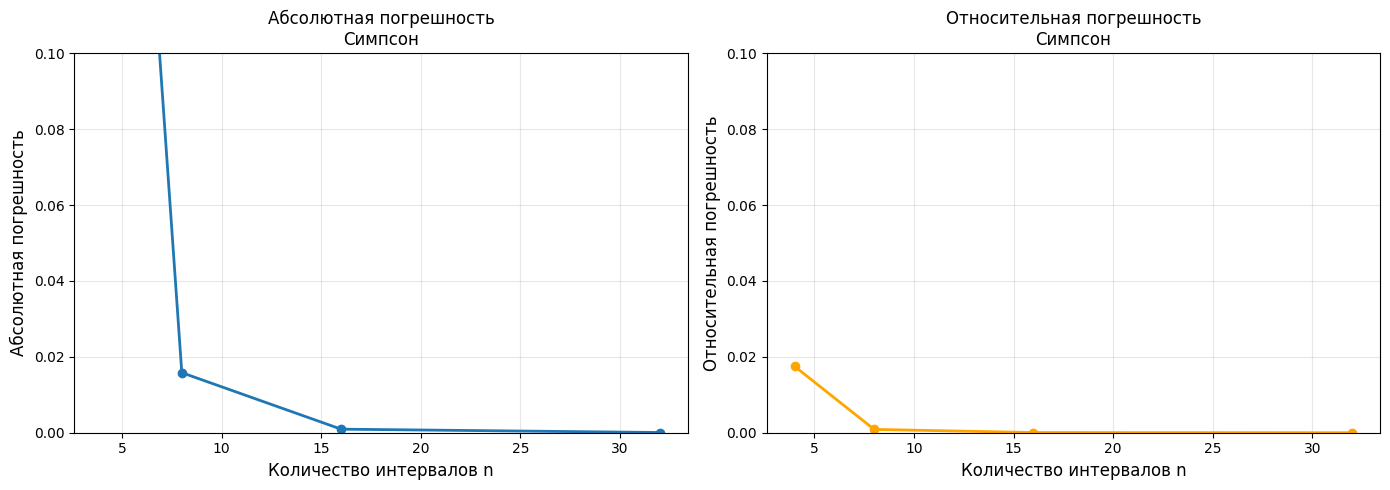

/tmp/ipykernel_7606/3273256915.py:120: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(*y_lim_absolute)


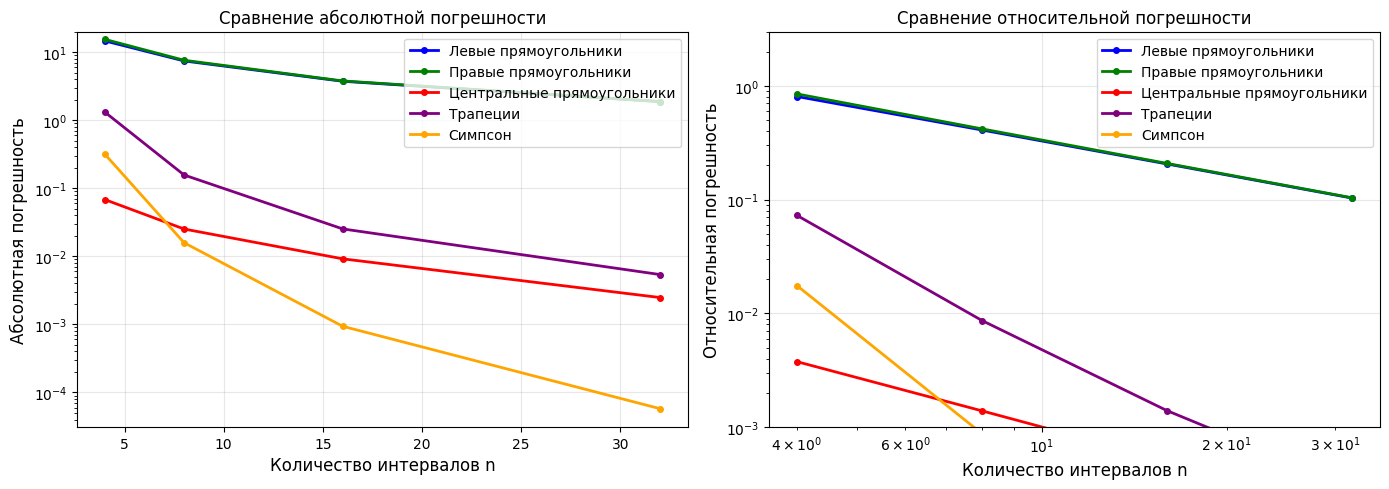

In [7]:
splits = [pow(2, i) for i in range(2, 6)]
Drawer.plot_errors(LeftRectangleMethod, ANALYTIC_VALUE, 0, 5, f, splits,
                   method_name="Левые прямоугольники")
Drawer.plot_errors(RightRectangleMethod, ANALYTIC_VALUE, 0, 5, f, splits,
                   method_name="Правые прямоугольники")
Drawer.plot_errors(MiddleRectangleMethod, ANALYTIC_VALUE, 0, 5, f, splits,
                   method_name="Центральные прямоугольники", y_lim_absolute=(0, 1e-1), y_lim_rel=(0, 1e-1))
Drawer.plot_errors(TrapezoidMethod, ANALYTIC_VALUE, 0, 5, f, splits,
                   method_name="Трапеции", y_lim_absolute=(0, 1e-1), y_lim_rel=(0, 1e-1))
Drawer.plot_errors(SimpsonMethod, ANALYTIC_VALUE, 0, 5, f, splits,
                   method_name="Симпсон", y_lim_absolute=(0, 1e-1), y_lim_rel=(0, 1e-1))

splits = [pow(2, i) for i in range(2, 6)]
Drawer.plot_all_methods_errors(
    [LeftRectangleMethod, RightRectangleMethod, MiddleRectangleMethod, TrapezoidMethod, SimpsonMethod],
    ["Левые прямоугольники", "Правые прямоугольники", "Центральные прямоугольники", "Трапеции",
     "Симпсон"], ANALYTIC_VALUE, [0, 5], f, splits)

По графикам абсолютно четко видно, что:
   - методы левых и правых прямоугольников показывают наихудшую сходимость
   - метод трапеций обеспечивает заметно лучшую скорость сходимости по сравнению с левыми и правыми прямоугольниками, однако в общем случае тоже сильно отстает от двух следующих методов
   - методы Симпсона и центральных прямоугольников демонстрируют самую быструю сходимость, при этом на начальных этапах, если брать малое число интервалов разбиения, то метод центральных прямоугольников даже выигрывает. С дальнейшими уменьшениями диаметра разбиений эта разница пропадает 

### 5. Задание 2

В данной части требуется, используя формулы апостериорной оценки погрешности, построить графики зависимости погрешности каждого метода от количества интервалов разбиения. Для оси абсцисс и оси ординат
использован логарифмический масштаб. Для значений погрешностей использован
интервал [10^(-5), 10^(-2)] с шагом 25х10^(-6).  

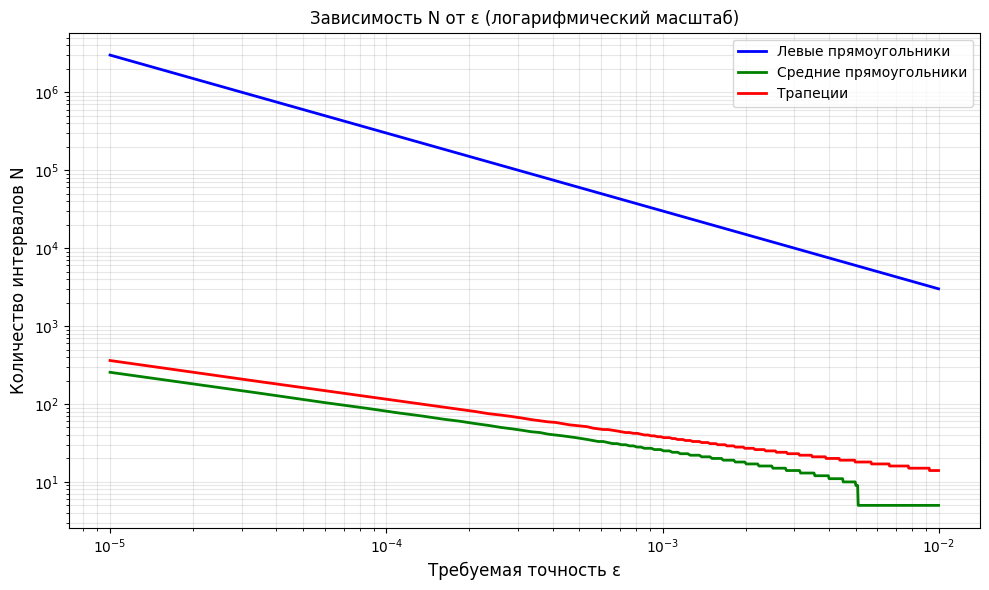

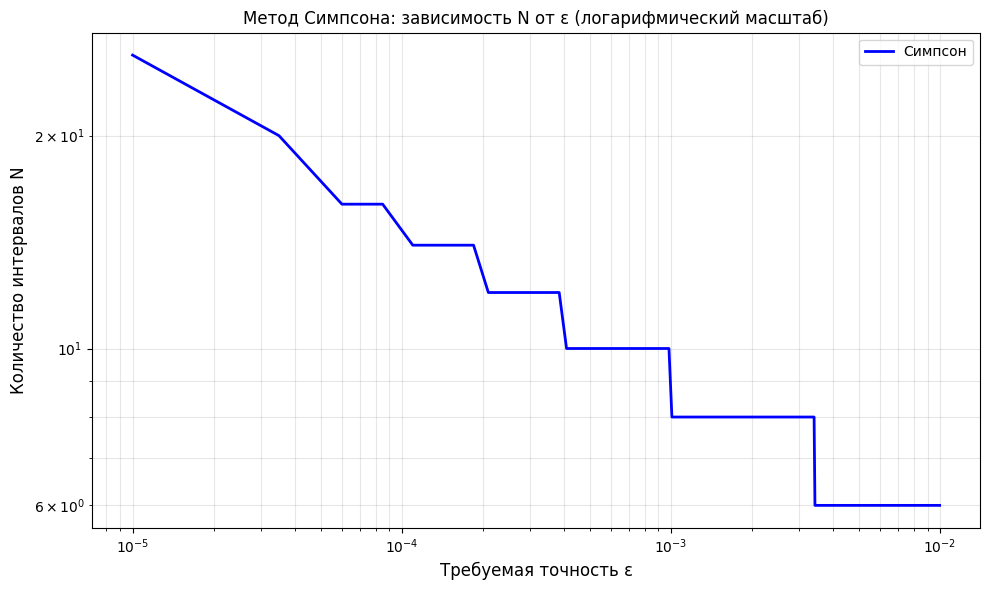

In [34]:
accuracy_values = [1e-5 + i * 25e-6 for i in range(int((1e-2 - 1e-5) / 25e-6) + 1)]
Drawer.plot_n_vs_accuracy(
    integrator_classes=[LeftRectangleMethod, MiddleRectangleMethod, TrapezoidMethod],
    method_names=["Левые прямоугольники", "Средние прямоугольники", "Трапеции"],
    a=0, b=5,
    func=f,
    accuracy_values=accuracy_values,
    title="Зависимость N от ε (логарифмический масштаб)"
)

Drawer.plot_n_vs_accuracy(
    integrator_classes=[SimpsonMethod],
    method_names=["Симпсон"],
    a=0, b=5,
    func=f,
    accuracy_values=accuracy_values,
    title="Метод Симпсона: зависимость N от ε (логарифмический масштаб)"
)

Здесь мы можем заметить, что:
- методу левых прямоугольников требуется самое большое число итераций, чтобы достичь требуемой точности. Этот метод требует больше чем в два раза больше итераций по сравнению с методом трапеций
- методы трапеций и центральных прямоугольников достигают требуемую точность достаточно быстро, но в общем случае метод средних прямоугольников делает это быстрее
- метод Симпсона достигает требуемой точности сильно быстрее, чем другие методы, иногда разница с ближайшим преследователем составляет два раза

### 6. Задание 3

В этом задании требуется сравнить метод Монте-Карло с методом левых прямоугольников. Для этого необходимо построить графики зависимости погрешности от числа итераций. В данном случае это будет делаться отдельно для случая одинарного интеграла и отдельно для тройного 

/tmp/ipykernel_7606/3273256915.py:120: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(*y_lim_absolute)


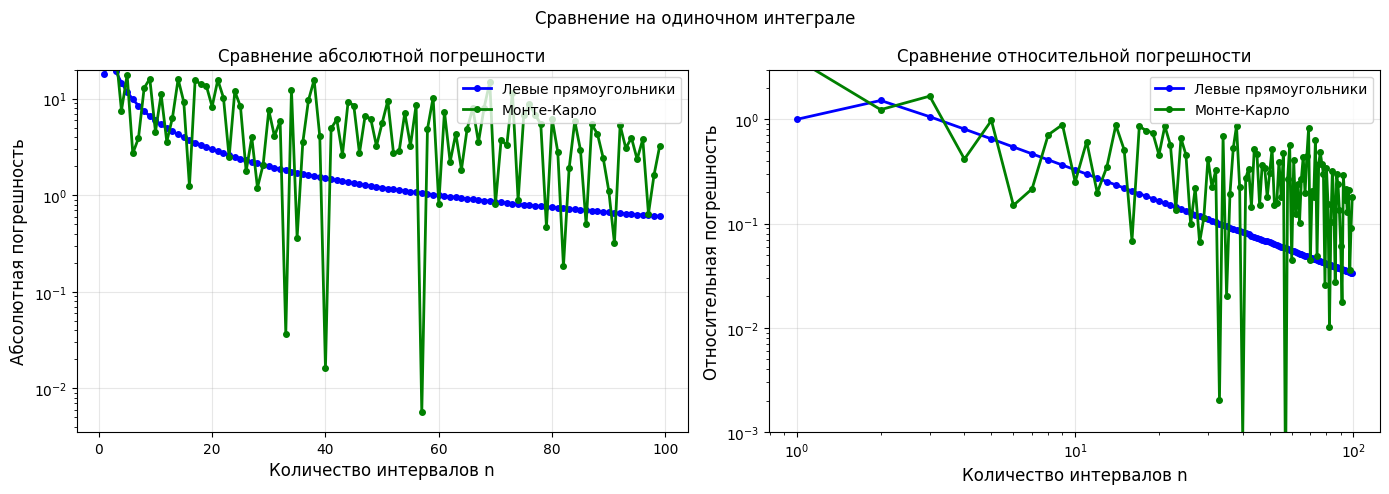

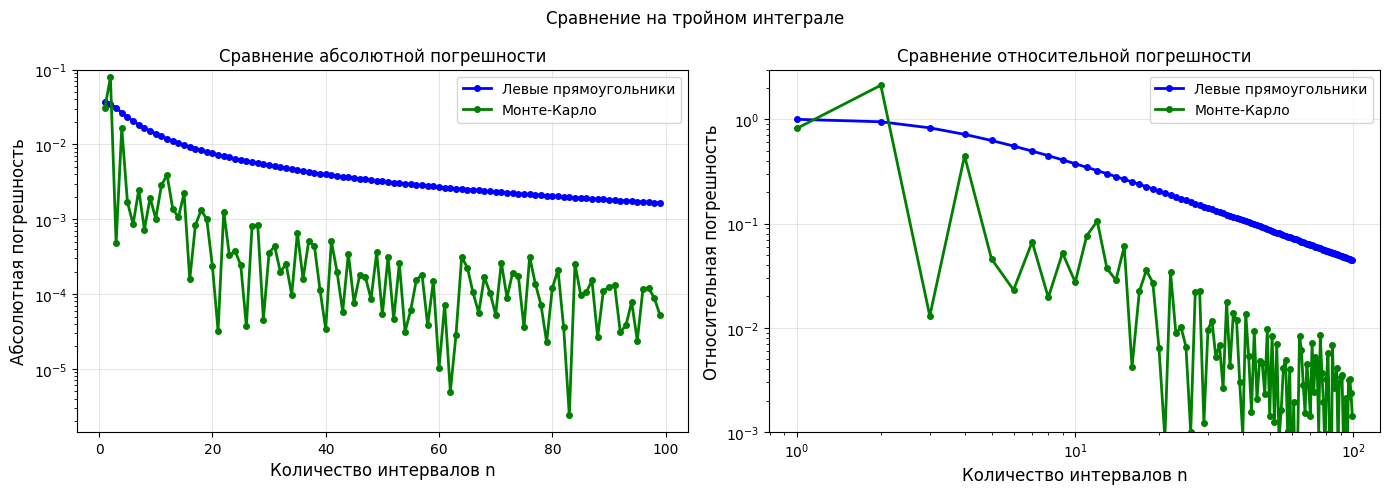

In [10]:
splits = [i for i in range(1, 100)]
Drawer.plot_all_methods_errors([LeftRectangleMethod, MonteCarloMethod], ["Левые прямоугольники", "Монте-Карло"],
                               ANALYTIC_VALUE, [0, 5], f, splits, title="Сравнение на одиночном интеграле")

Drawer.plot_all_methods_errors([LeftRectangleMethod, MonteCarloMethod], ["Левые прямоугольники", "Монте-Карло"],
                               ANALYTIC_VALUE_TRIPLE, [0, 1, 0, 1, 0, 1], f1, splits,
                               title="Сравнение на тройном интеграле", method_from_getattr_name='integrate_triple',
                               y_lim_absolute=(0, 1e-1))

По графикам заметно, что:
- методы Монте-Карло и левых прямоугольников сходятся с похожей скоростью. Иногда метод Монте-Карло сходится немного быстрее, иногда немного проигрывает. В целом скорость сходимости очень похожа у методов